In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:

def seam_carving(image, seams_number, depth_map=None, saliency_map=None, visualize=False):
    """Perform Seam Carving to reduce image width by seams_number columns.

    Args:
        image: Input image (H, W, 3) as float32 in [0, 1].
        seams_number: Number of vertical seams to remove.
        depth_map: Optional depth map (H, W) as float32.
        saliency_map: Optional saliency map (H, W) as float32.
        visualize: If True, display seams during processing.

    Returns:
        resized_image: Image with reduced width.
        seam_energies: List of cumulative energies of removed seams.
    """
    img_copy = np.copy(image)
    dmap_copy = np.copy(depth_map) if depth_map is not None else None
    smap_copy = np.copy(saliency_map) if saliency_map is not None else None

    seam_energies_log = []

    for i in range(seams_number):
        print(f"Removing seam {i + 1}/{seams_number}")

        gray = cv2.cvtColor((img_copy * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY)
        grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        energy_map = np.abs(grad_x) + np.abs(grad_y)

        if smap_copy is not None:
            energy_map += smap_copy * np.max(energy_map)
        if dmap_copy is not None:
            energy_map += (1 - dmap_copy) * np.max(energy_map)

        h, w = energy_map.shape
        cumulative_map = np.copy(energy_map)

        for row in range(1, h):
            for col in range(w):
                if col == 0:
                    min_prev_energy = np.min(cumulative_map[row - 1, col:col + 2])
                elif col == w - 1:
                    min_prev_energy = np.min(cumulative_map[row - 1, col - 1:col + 1])
                else:
                    min_prev_energy = np.min(cumulative_map[row - 1, col - 1:col + 2])
                cumulative_map[row, col] += min_prev_energy

        seam_path = np.zeros(h, dtype=np.uint32)
        min_col = np.argmin(cumulative_map[-1, :])
        seam_path[-1] = min_col
        seam_energies_log.append(cumulative_map[-1, min_col])

        for row in range(h - 2, -1, -1):
            prev_col = seam_path[row + 1]
            if prev_col == 0:
                min_idx = np.argmin(cumulative_map[row, prev_col:prev_col + 2])
                seam_path[row] = prev_col + min_idx
            elif prev_col == w - 1:
                min_idx = np.argmin(cumulative_map[row, prev_col - 1:prev_col + 1])
                seam_path[row] = prev_col - 1 + min_idx
            else:
                min_idx = np.argmin(cumulative_map[row, prev_col - 1:prev_col + 2])
                seam_path[row] = prev_col - 1 + min_idx

        if visualize and (i + 1) % 20 == 0:
            vis_img = np.copy(img_copy)
            for row in range(h):
                vis_img[row, seam_path[row]] = [0, 0, 1]
            plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
            plt.title(f"Seam #{i + 1}")
            plt.axis('off')
            plt.show()

        mask = np.ones((h, w), dtype=bool)
        for row in range(h):
            mask[row, seam_path[row]] = False

        img_copy = img_copy[mask].reshape(h, w - 1, 3)

        if smap_copy is not None:
            smap_copy = smap_copy[mask].reshape(h, w - 1)
        if dmap_copy is not None:
            dmap_copy = dmap_copy[mask].reshape(h, w - 1)

    return img_copy, seam_energies_log

In [9]:
# Load images and maps
baby_path = 'Baby.png'
baby_dmap_path = 'Baby_DMap.png'
baby_smap_path = 'Baby_SMap.png'

baby = cv2.imread(baby_path).astype(np.float32) / 255.0
baby_dmap = cv2.imread(baby_dmap_path, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
baby_smap = cv2.imread(baby_smap_path, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

# Parameters
seams_number = 200
visualize = True # Set to False to run faster without visualizations

Removing seam 1/200
Removing seam 2/200
Removing seam 3/200
Removing seam 4/200
Removing seam 5/200
Removing seam 6/200
Removing seam 7/200
Removing seam 8/200
Removing seam 9/200
Removing seam 10/200
Removing seam 11/200
Removing seam 12/200
Removing seam 13/200
Removing seam 14/200
Removing seam 15/200
Removing seam 16/200
Removing seam 17/200
Removing seam 18/200
Removing seam 19/200
Removing seam 20/200


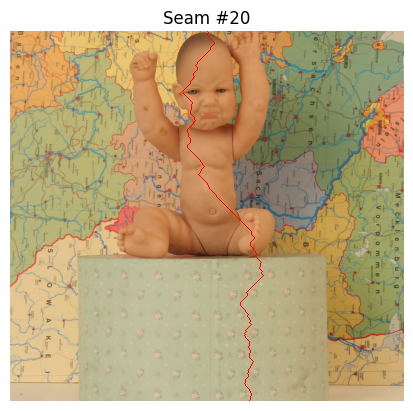

Removing seam 21/200
Removing seam 22/200
Removing seam 23/200
Removing seam 24/200
Removing seam 25/200
Removing seam 26/200
Removing seam 27/200
Removing seam 28/200
Removing seam 29/200
Removing seam 30/200
Removing seam 31/200
Removing seam 32/200
Removing seam 33/200
Removing seam 34/200
Removing seam 35/200
Removing seam 36/200
Removing seam 37/200
Removing seam 38/200
Removing seam 39/200
Removing seam 40/200


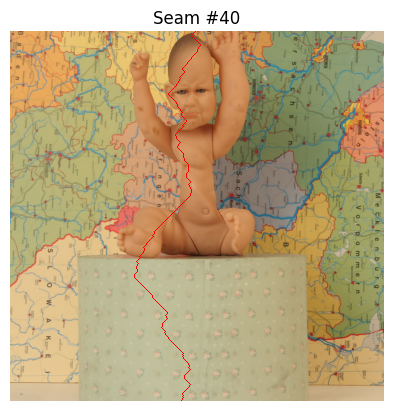

Removing seam 41/200
Removing seam 42/200
Removing seam 43/200
Removing seam 44/200
Removing seam 45/200
Removing seam 46/200
Removing seam 47/200
Removing seam 48/200
Removing seam 49/200
Removing seam 50/200
Removing seam 51/200
Removing seam 52/200
Removing seam 53/200
Removing seam 54/200
Removing seam 55/200
Removing seam 56/200
Removing seam 57/200
Removing seam 58/200
Removing seam 59/200
Removing seam 60/200


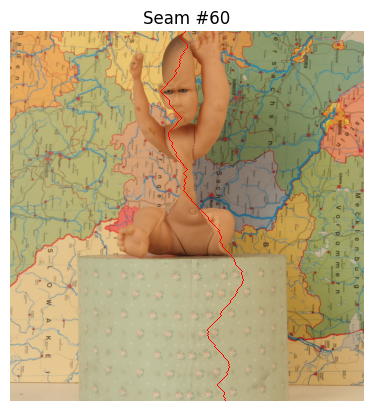

Removing seam 61/200
Removing seam 62/200
Removing seam 63/200
Removing seam 64/200
Removing seam 65/200
Removing seam 66/200
Removing seam 67/200
Removing seam 68/200
Removing seam 69/200
Removing seam 70/200
Removing seam 71/200
Removing seam 72/200
Removing seam 73/200
Removing seam 74/200
Removing seam 75/200
Removing seam 76/200
Removing seam 77/200
Removing seam 78/200
Removing seam 79/200
Removing seam 80/200


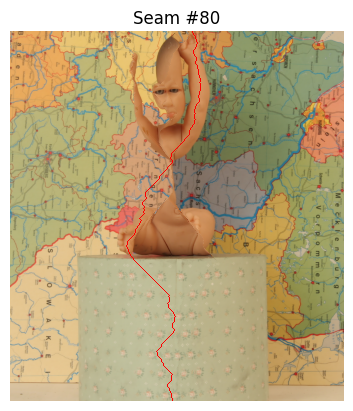

Removing seam 81/200
Removing seam 82/200
Removing seam 83/200
Removing seam 84/200
Removing seam 85/200
Removing seam 86/200
Removing seam 87/200
Removing seam 88/200
Removing seam 89/200
Removing seam 90/200
Removing seam 91/200
Removing seam 92/200
Removing seam 93/200
Removing seam 94/200
Removing seam 95/200
Removing seam 96/200
Removing seam 97/200
Removing seam 98/200
Removing seam 99/200
Removing seam 100/200


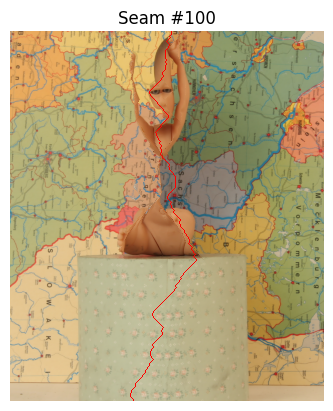

Removing seam 101/200
Removing seam 102/200
Removing seam 103/200
Removing seam 104/200
Removing seam 105/200
Removing seam 106/200
Removing seam 107/200
Removing seam 108/200
Removing seam 109/200
Removing seam 110/200
Removing seam 111/200
Removing seam 112/200
Removing seam 113/200
Removing seam 114/200
Removing seam 115/200
Removing seam 116/200
Removing seam 117/200
Removing seam 118/200
Removing seam 119/200
Removing seam 120/200


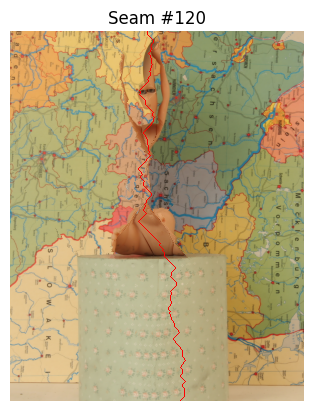

Removing seam 121/200
Removing seam 122/200
Removing seam 123/200
Removing seam 124/200
Removing seam 125/200
Removing seam 126/200
Removing seam 127/200
Removing seam 128/200
Removing seam 129/200
Removing seam 130/200
Removing seam 131/200
Removing seam 132/200
Removing seam 133/200
Removing seam 134/200
Removing seam 135/200
Removing seam 136/200
Removing seam 137/200
Removing seam 138/200
Removing seam 139/200
Removing seam 140/200


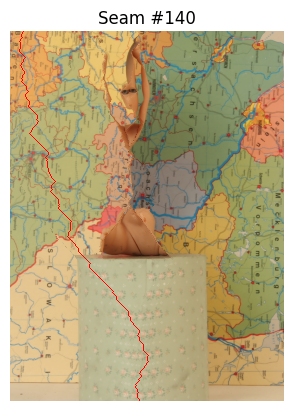

Removing seam 141/200
Removing seam 142/200
Removing seam 143/200
Removing seam 144/200
Removing seam 145/200
Removing seam 146/200
Removing seam 147/200
Removing seam 148/200
Removing seam 149/200
Removing seam 150/200
Removing seam 151/200
Removing seam 152/200
Removing seam 153/200
Removing seam 154/200
Removing seam 155/200
Removing seam 156/200
Removing seam 157/200
Removing seam 158/200
Removing seam 159/200
Removing seam 160/200


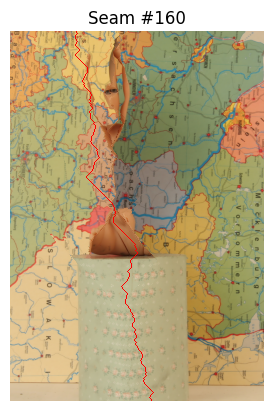

Removing seam 161/200
Removing seam 162/200
Removing seam 163/200
Removing seam 164/200
Removing seam 165/200
Removing seam 166/200
Removing seam 167/200
Removing seam 168/200
Removing seam 169/200
Removing seam 170/200
Removing seam 171/200
Removing seam 172/200
Removing seam 173/200
Removing seam 174/200
Removing seam 175/200
Removing seam 176/200
Removing seam 177/200
Removing seam 178/200
Removing seam 179/200
Removing seam 180/200


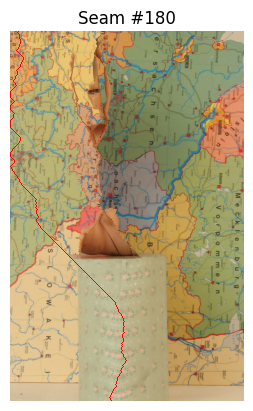

Removing seam 181/200
Removing seam 182/200
Removing seam 183/200
Removing seam 184/200
Removing seam 185/200
Removing seam 186/200
Removing seam 187/200
Removing seam 188/200
Removing seam 189/200
Removing seam 190/200
Removing seam 191/200
Removing seam 192/200
Removing seam 193/200
Removing seam 194/200
Removing seam 195/200
Removing seam 196/200
Removing seam 197/200
Removing seam 198/200
Removing seam 199/200
Removing seam 200/200


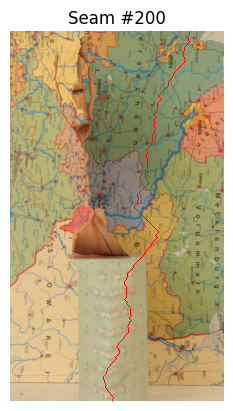

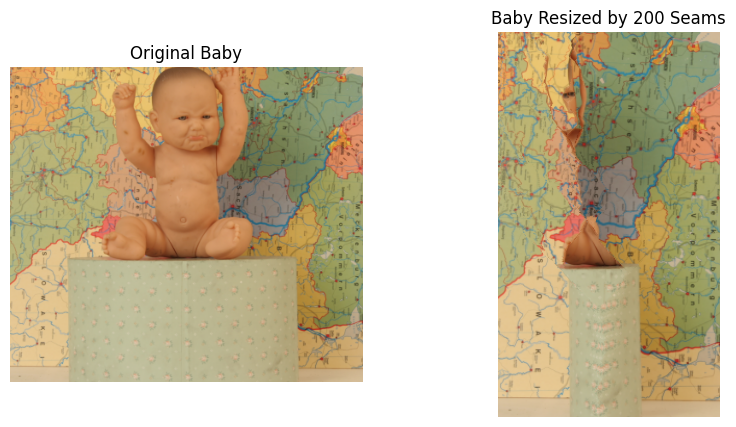

True

In [10]:
# Process images
baby_resized, baby_energies = seam_carving(baby, seams_number, baby_dmap, baby_smap, visualize)

# Save seam energies
with open('seam_energy_log.txt', 'w') as f:
    f.write('Baby Seam Energies:\n' + '\n'.join(map(str, baby_energies)) + '\n')

# Visualize final result
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(baby, cv2.COLOR_BGR2RGB))
plt.title('Original Baby')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(baby_resized, cv2.COLOR_BGR2RGB))
plt.title(f'Baby Resized by {seams_number} Seams')
plt.axis('off')

plt.show()

# Save resized images
cv2.imwrite('Baby_resized.png', (baby_resized * 255).astype(np.uint8))

این تسک شامل پیاده‌سازی دو الگوریتم پردازش تصویر از ابتدا بود:

کاهش رنگ با K-means: در این بخش، الگوریتم K-means برای کاهش تعداد رنگ‌های یک تصویر به ۱۶ رنگ پیاده‌سازی شد. این الگوریتم با یافتن مراکز رنگی میانگین و تخصیص هر پیکسل به نزدیک‌ترین مرکز، تصویر را فشرده می‌کند. کیفیت نهایی با معیار L2 Norm ارزیابی شد.

تغییر ابعاد با Seam Carving: در بخش دوم، الگوریتم Seam Carving برای کاهش هوشمندانه عرض تصویر پیاده‌سازی شد. این الگوریتم با تعریف یک نقشه انرژی ترکیبی (شامل لبه‌ها، نقشه عمق و نقشه برجستگی)، کم‌اهمیت‌ترین مسیرهای عمودی پیکسل‌ها (درزها) را پیدا و حذف می‌کند. در نتیجه، عرض تصویر بدون آسیب رساندن به سوژه اصلی کاهش می‌یابد.







